##### **DBSCAN (Density-Based Spatial Clustering of Applications with Noise) Clustering**

DBSCAN clustering is an **unsupervised clustering algorithm** that groups data points based on how densely packed they are, rather than how close they are to a predefined center.
DBSCAN forms clusters by identifying regions of high point density separated by regions of low density.

This is usually applicable in cases where one group of data points kind of wraps the other group. Traditionally, K nearest Neighbours fails here. 

It relies on two key parameters:

- ε (epsilon) – the radius that defines a neighborhood around a point
- MinPts – the minimum number of points required to form a dense region

Based on these, points are classified as:

- Core points: have at least MinPts neighbors within ε
- Border points: are within ε of a core point but don’t have enough neighbors themselves
- Noise (outliers): don’t belong to any cluster

Clusters grow by connecting neighboring core points together.

**Why is DBSCAN needed?**

DBSCAN solves several problems that other clustering algorithms (like k-means) struggle with.

1. No need to predefine number of clusters

Unlike k-means, DBSCAN automatically finds the number of clusters.

2. Handles arbitrary cluster shapes

It can find:

    - Curved clusters
    - Elongated clusters
    - Irregular shapes

K-means assumes spherical clusters; DBSCAN doesn’t.

3. Robust to noise and outliers

DBSCAN explicitly labels noise points, instead of forcing every point into a cluster.

4. Works well when density matters

When clusters are defined by dense regions, DBSCAN often performs better than distance-based methods.

**Steps**
- We initiate core points randomly
- We check if it is surrounded by min points or not?
    - If Yes, mark all the points it is touching as *core points*
    - If No, proceed to another  random point
- We will start with random core point with epsilon as area. 
- Assign data points as similar groupwhich are core points
- For data points which are similar ut non core will be merged in group but not allowed to further etend the group. 


1) Create core & non core points
2) from core point create group using data near to the point 
3) Not non core points which are near to the above process
4) group them but they are still non core
5) Groups + outliers

##### **DBScan Clustering Practical**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import scipy.cluster.hierarchy as sch

In [2]:
df = pd.read_csv("data/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


##### DBSCAN Clustering

- eps = how close points must be to be considered neighbors
- min_samples = minimum points required to form a cluster
- Points labeled -1 are outliers

In [3]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].values

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
db = DBSCAN(eps=0.32, min_samples=5)
labels_db = db.fit_predict(X_scaled)

In [6]:
colors = ['black' if label == -1 else plt.cm.tab10(label / 10) for label in labels_db]

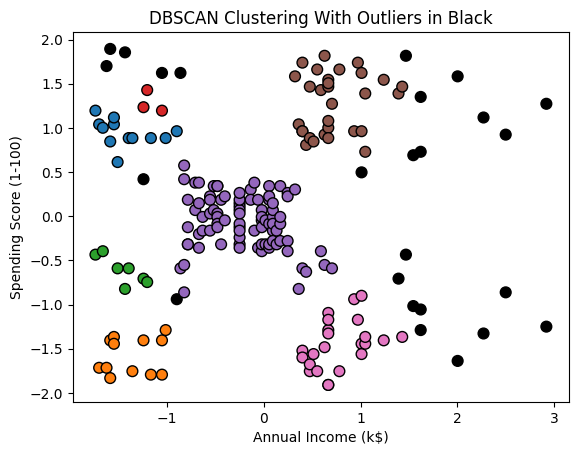

In [ ]:
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=colors,
    s=60, # how big the circles will be in my plot
    edgecolor='k' #black edge
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("DBSCAN Clustering With Outliers in Black")
plt.show()